# Customer Churn Prediction Using Machine Learning

**B.Tech AI & ML — First Year Project**

### Objective
Predict whether a telecom customer is likely to leave the service (`Churn = Yes`) using supervised machine learning.

### Project workflow
1. Load and understand the dataset
2. Clean and preprocess the data
3. Explore important patterns
4. Train multiple classification models
5. Compare their performance
6. Evaluate the selected model
7. Inspect feature importance
8. Make a sample prediction

**Dataset source:** IBM Telco Customer Churn sample dataset. The dataset contains customer/account/service information and a binary `Churn` target.

## 1. Import Libraries

In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42

## 2. Load the Dataset

The dataset is loaded directly from the IBM-hosted GitHub source so the notebook can be run in Google Colab without manually uploading the CSV.

In [28]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Understand the Dataset

In [29]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
display(df["Churn"].value_counts())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Missing values:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Target distribution:


,count
Churn,
No,5174
Yes,1869


## 4. Data Cleaning

`TotalCharges` is stored as text in this dataset. We convert it to numeric values and let the preprocessing pipeline handle any resulting missing values.

In [30]:
df = df.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Customer ID is an identifier, not a useful predictive feature.
df = df.drop(columns=["customerID"])

print("Missing values after conversion:")
display(df.isna().sum()[df.isna().sum() > 0])

Missing values after conversion:


,0
TotalCharges,11


## 5. Exploratory Data Analysis

A few simple plots are used to understand how churn relates to contract type, tenure, and monthly charges.

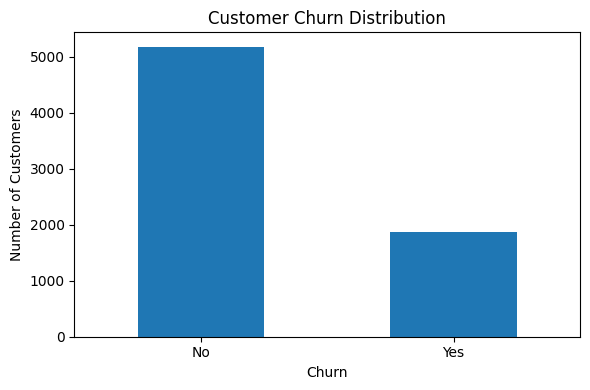

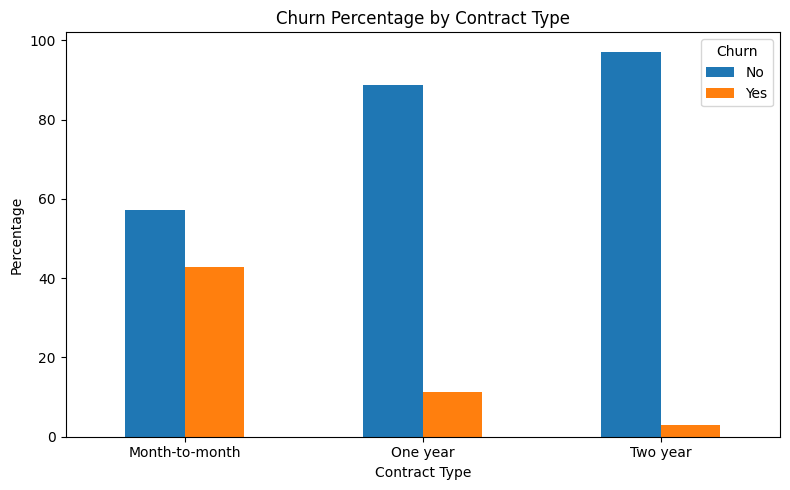

<Figure size 800x500 with 0 Axes>

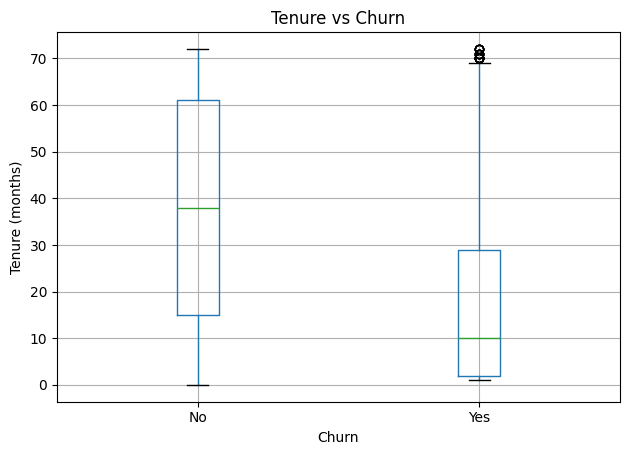

<Figure size 800x500 with 0 Axes>

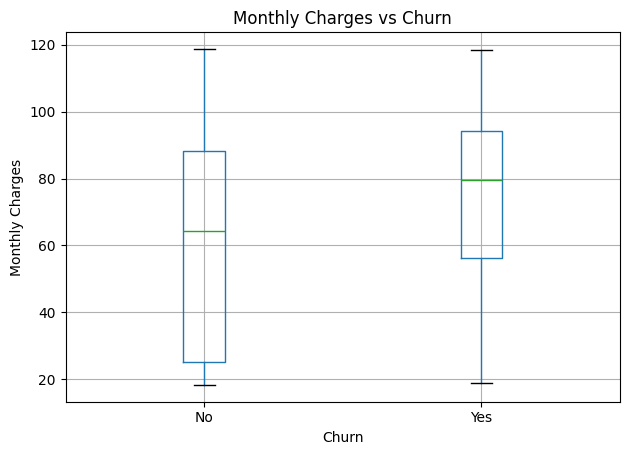

In [31]:
# Churn distribution
plt.figure(figsize=(6,4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Contract vs churn
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
contract_churn.plot(kind="bar", figsize=(8,5))
plt.title("Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Tenure distribution by churn
plt.figure(figsize=(8,5))
df.boxplot(column="tenure", by="Churn")
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.tight_layout()
plt.show()

# Monthly charges by churn
plt.figure(figsize=(8,5))
df.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

## 6. Prepare Features and Target

In [32]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training samples: 5634
Testing samples: 1409


## 7. Preprocessing Pipeline

Numerical features are imputed and standardized. Categorical features are imputed and one-hot encoded.

Using a pipeline keeps preprocessing inside the training workflow and helps prevent data leakage from the test set.

In [33]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 8. Train Multiple Machine Learning Models

We compare four classification algorithms:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

In [34]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250, max_depth=10, random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = []
pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })
    pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("F1 Score", ascending=False)
display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040
3,Gradient Boosting,0.8062,0.6735,0.5241,0.5895
2,Random Forest,0.8041,0.6678,0.5214,0.5856
1,Decision Tree,0.7913,0.6342,0.5053,0.5625


## 9. Compare Model Performance

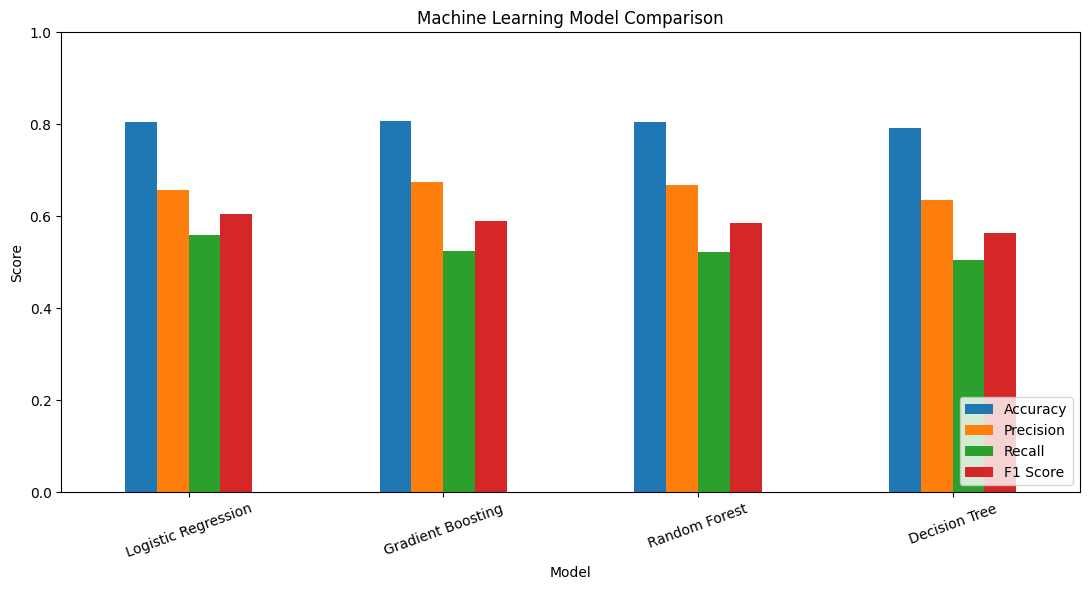

In [35]:
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]

ax = plot_df.plot(kind="bar", figsize=(11,6))
plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 10. Select and Evaluate the Best Model

For churn prediction, F1 score is useful because it balances precision and recall. We select the model with the highest test-set F1 score from the comparison above.

In [36]:
best_model_name = results_df.iloc[0]["Model"]
best_model = pipelines[best_model_name]

best_pred = best_model.predict(X_test)

print("Selected model:", best_model_name)
print()
print(classification_report(
    y_test,
    best_pred,
    target_names=["No Churn", "Churn"],
    zero_division=0
))

Selected model: Logistic Regression

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## 11. Confusion Matrix

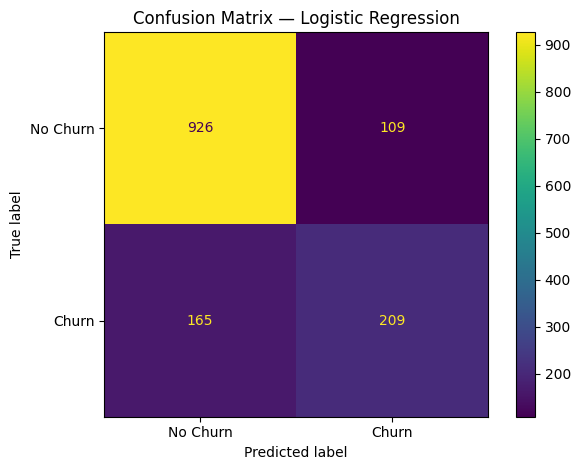

In [37]:
cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

## 12. Feature Importance

For tree-based models, we show the most influential features when the selected model provides feature importances. For Logistic Regression, absolute coefficients are used instead.

,Feature,Importance
1,num__tenure,1.241319
38,cat__Contract_Two year,0.772261
15,cat__InternetService_DSL,0.652406
16,cat__InternetService_Fiber optic,0.640026
2,num__MonthlyCharges,0.596392
36,cat__Contract_Month-to-month,0.579304
3,num__TotalCharges,0.516708
39,cat__PaperlessBilling_No,0.343260
25,cat__DeviceProtection_No internet service,0.301082
17,cat__InternetService_No,0.301082


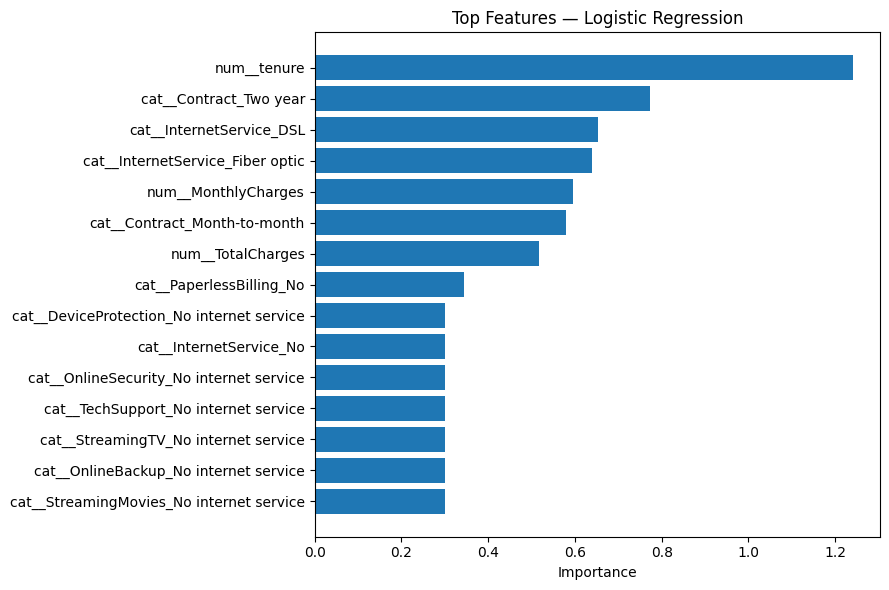

In [38]:
model_object = best_model.named_steps["model"]
preprocessor_fitted = best_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

if hasattr(model_object, "feature_importances_"):
    importance = model_object.feature_importances_
elif hasattr(model_object, "coef_"):
    importance = np.abs(model_object.coef_[0])
else:
    importance = None

if importance is not None:
    feature_importance = (
        pd.DataFrame({"Feature": feature_names, "Importance": importance})
        .sort_values("Importance", ascending=False)
        .head(15)
    )

    display(feature_importance)

    plt.figure(figsize=(9,6))
    plt.barh(
        feature_importance["Feature"][::-1],
        feature_importance["Importance"][::-1]
    )
    plt.title(f"Top Features — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not available for this model.")

## 13. Example Prediction

The following example uses one customer from the test set and predicts whether the customer is likely to churn.

In [39]:
sample_customer = X_test.iloc[[0]]
actual = y_test.iloc[0]

prediction = best_model.predict(sample_customer)[0]

print("Predicted:", "Churn" if prediction == 1 else "No Churn")
print("Actual:", "Churn" if actual == 1 else "No Churn")

display(sample_customer)

Predicted: No Churn
Actual: No Churn


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2


## 14. Conclusion

This project demonstrates a complete supervised machine-learning workflow for customer churn prediction. The work includes data cleaning, exploratory analysis, preprocessing, multiple model training, evaluation, confusion-matrix analysis, and feature-importance analysis.

### Possible future improvements
- Hyperparameter tuning
- Cross-validation
- Probability calibration
- Handling class imbalance with techniques such as class weights or resampling
- Deploying the selected model as a simple web application

## References

- IBM Telco Customer Churn sample data
- Scikit-learn documentation for preprocessing, pipelines, classification and evaluation metrics

**Note:** Model results can vary slightly depending on library versions and execution environment.

In [41]:
# 14. Project Summary and Key Findings

print("KEY FINDINGS")
print("=" * 50)

print("1. Month-to-month customers show a higher churn rate than customers")
print("   with one-year or two-year contracts.")

print("\n2. Customers who churn generally have lower tenure.")

print("\n3. Monthly charges show a noticeable relationship with churn.")

print("\n4. Four machine-learning models were compared:")
print("   Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.")

print("\n5. Logistic Regression achieved the highest F1 score among the")
print("   tested models and was selected as the final model.")

print("\n6. The model demonstrates that customer information can be used")
print("   to identify patterns associated with customer churn.")

KEY FINDINGS
1. Month-to-month customers show a higher churn rate than customers
   with one-year or two-year contracts.

2. Customers who churn generally have lower tenure.

3. Monthly charges show a noticeable relationship with churn.

4. Four machine-learning models were compared:
   Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

5. Logistic Regression achieved the highest F1 score among the
   tested models and was selected as the final model.

6. The model demonstrates that customer information can be used
   to identify patterns associated with customer churn.


## 14. Key Findings and Conclusion

The analysis shows that customer churn is associated with several customer and service-related factors. Month-to-month contracts show a higher churn rate than longer-term contracts, while customers with longer tenure generally show lower churn.

Four machine-learning classification models were compared: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Logistic Regression was selected as the final model because it achieved the highest F1 score among the tested models.

The project demonstrates how machine learning can be used to identify customers who may be at risk of leaving a service. In the future, the project can be improved through hyperparameter tuning, cross-validation, better handling of class imbalance, and deployment as a web application.